# Real Forward Inspection

This notebook inspects what happens during a real prediction of the trained ResNet50 baseline. It uses the project DataLoader, the saved checkpoint and forward hooks on the actual PyTorch model.

The goal is not to simulate the network. The goal is to observe the real intermediate tensors used by the classifier: input tensor, convolutional stages, residual layers, logits, softmax probabilities and the Grad-CAM target layer.

In [5]:
from pathlib import Path
from IPython.display import Image, display
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "scripts").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing src/ and scripts/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MANIFEST = PROJECT_ROOT / "data" / "AWA2_subset_background20" / "awa2_manifest_subset.csv"
CHECKPOINT = PROJECT_ROOT / "outputs" / "checkpoints" / "best_resnet50_awa2.pt"
OUTPUT = PROJECT_ROOT / "outputs" / "figures" / "real_forward_inspection_notebook.png"
TRACE_JSON = PROJECT_ROOT / "outputs" / "reports" / "real_forward_trace_notebook.json"

print("project_root:", PROJECT_ROOT)
print("manifest:", MANIFEST, "exists=", MANIFEST.exists())
print("checkpoint:", CHECKPOINT, "exists=", CHECKPOINT.exists())

project_root: /home/emma/DeepLearning/Deep_Learning_XAI
manifest: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv exists= True
checkpoint: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt exists= True


## Load one real sample

The selected sample comes from the same manifest used by the project. The transform is the standard ResNet preprocessing: resize, center crop, tensor conversion and ImageNet normalization.

In [6]:
from scripts.run_forward_inspection import infer_num_classes, load_class_names, load_checkpoint
from src.data import ImageManifestDataset, build_resnet_transforms
from src.model import build_resnet50_classifier, get_device
from src.forward_inspection import ForwardActivationInspector, print_trace_summary, save_prediction_trace_figure, save_trace_json
from src.utils import set_seed

set_seed(42)
device = get_device("auto")
num_classes = infer_num_classes(MANIFEST)
class_names = load_class_names(MANIFEST)

dataset = ImageManifestDataset(
    manifest_path=MANIFEST,
    split="test",
    transform=build_resnet_transforms(train=False),
)

SAMPLE_INDEX = 0
image, label, true_name, image_path = dataset[SAMPLE_INDEX]
print("device:", device)
print("num_classes:", num_classes)
print("image:", image_path)
print("true label:", int(label), true_name)
print("input tensor shape:", tuple(image.shape))

device: cpu
num_classes: 20
image: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/JPEGImages/antelope/antelope_10691.jpg
true label: 0 antelope
input tensor shape: (3, 224, 224)


## Run the real model and capture intermediate tensors

Forward hooks are attached to `conv1`, `maxpool`, `layer1`, `layer2`, `layer3`, `layer4` and `avgpool`. The notebook then performs one real forward pass and prints tensor statistics. The Grad-CAM map is computed on `layer4[-1]`, the last residual block.

In [7]:
model = build_resnet50_classifier(num_classes=num_classes, pretrained=False).to(device)
load_checkpoint(model, CHECKPOINT, device)
model.eval()

with ForwardActivationInspector(model) as inspector:
    trace = inspector.run(image=image, target_label=None, compute_gradcam=True)

print_trace_summary(trace, class_names)

predicted_label=0 predicted_name=antelope confidence=0.4785
top probabilities:
    0 antelope                 0.4785
    2 bobcat                   0.0509
    7 giraffe                  0.0484
   19 zebra                    0.0467
   15 sheep                    0.0331
tensor statistics:
  input          shape=(1, 3, 224, 224) min=-1.77311 max=1.47224 mean=-0.59504 std=0.37248
  logits         shape=(1, 20) min=-1.11895 max=2.20580 mean=-0.56271 std=0.72601
  probabilities  shape=(1, 20) min=0.01722 max=0.47851 mean=0.05000 std=0.10136
  conv1          shape=(1, 64, 112, 112) min=-21.56613 max=20.44967 mean=0.05555 std=1.61621
  maxpool        shape=(1, 64, 56, 56) min=0.00000 max=42.71157 mean=3.75277 std=4.32639
  layer1         shape=(1, 256, 56, 56) min=0.00000 max=16.32927 mean=1.16535 std=1.50664
  layer2         shape=(1, 512, 28, 28) min=0.00000 max=15.52984 mean=0.79733 std=1.37972
  layer3         shape=(1, 1024, 14, 14) min=0.00000 max=20.17132 mean=0.41736 std=0.93107
  laye

## Visual interpretation of the real forward pass

The figure shows the denormalized input image, activation summaries for the main ResNet stages, the Grad-CAM map, top softmax probabilities and a table of tensor statistics. The activation maps are not new model outputs: they are channel-reduced visual summaries of the real intermediate tensors.

The same trace is also exported as JSON. That JSON can be loaded into `docs/resnet_activation_simulator.html` to make the browser visualization use the real notebook/model output instead of synthetic values.

trace json: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/real_forward_trace_notebook.json


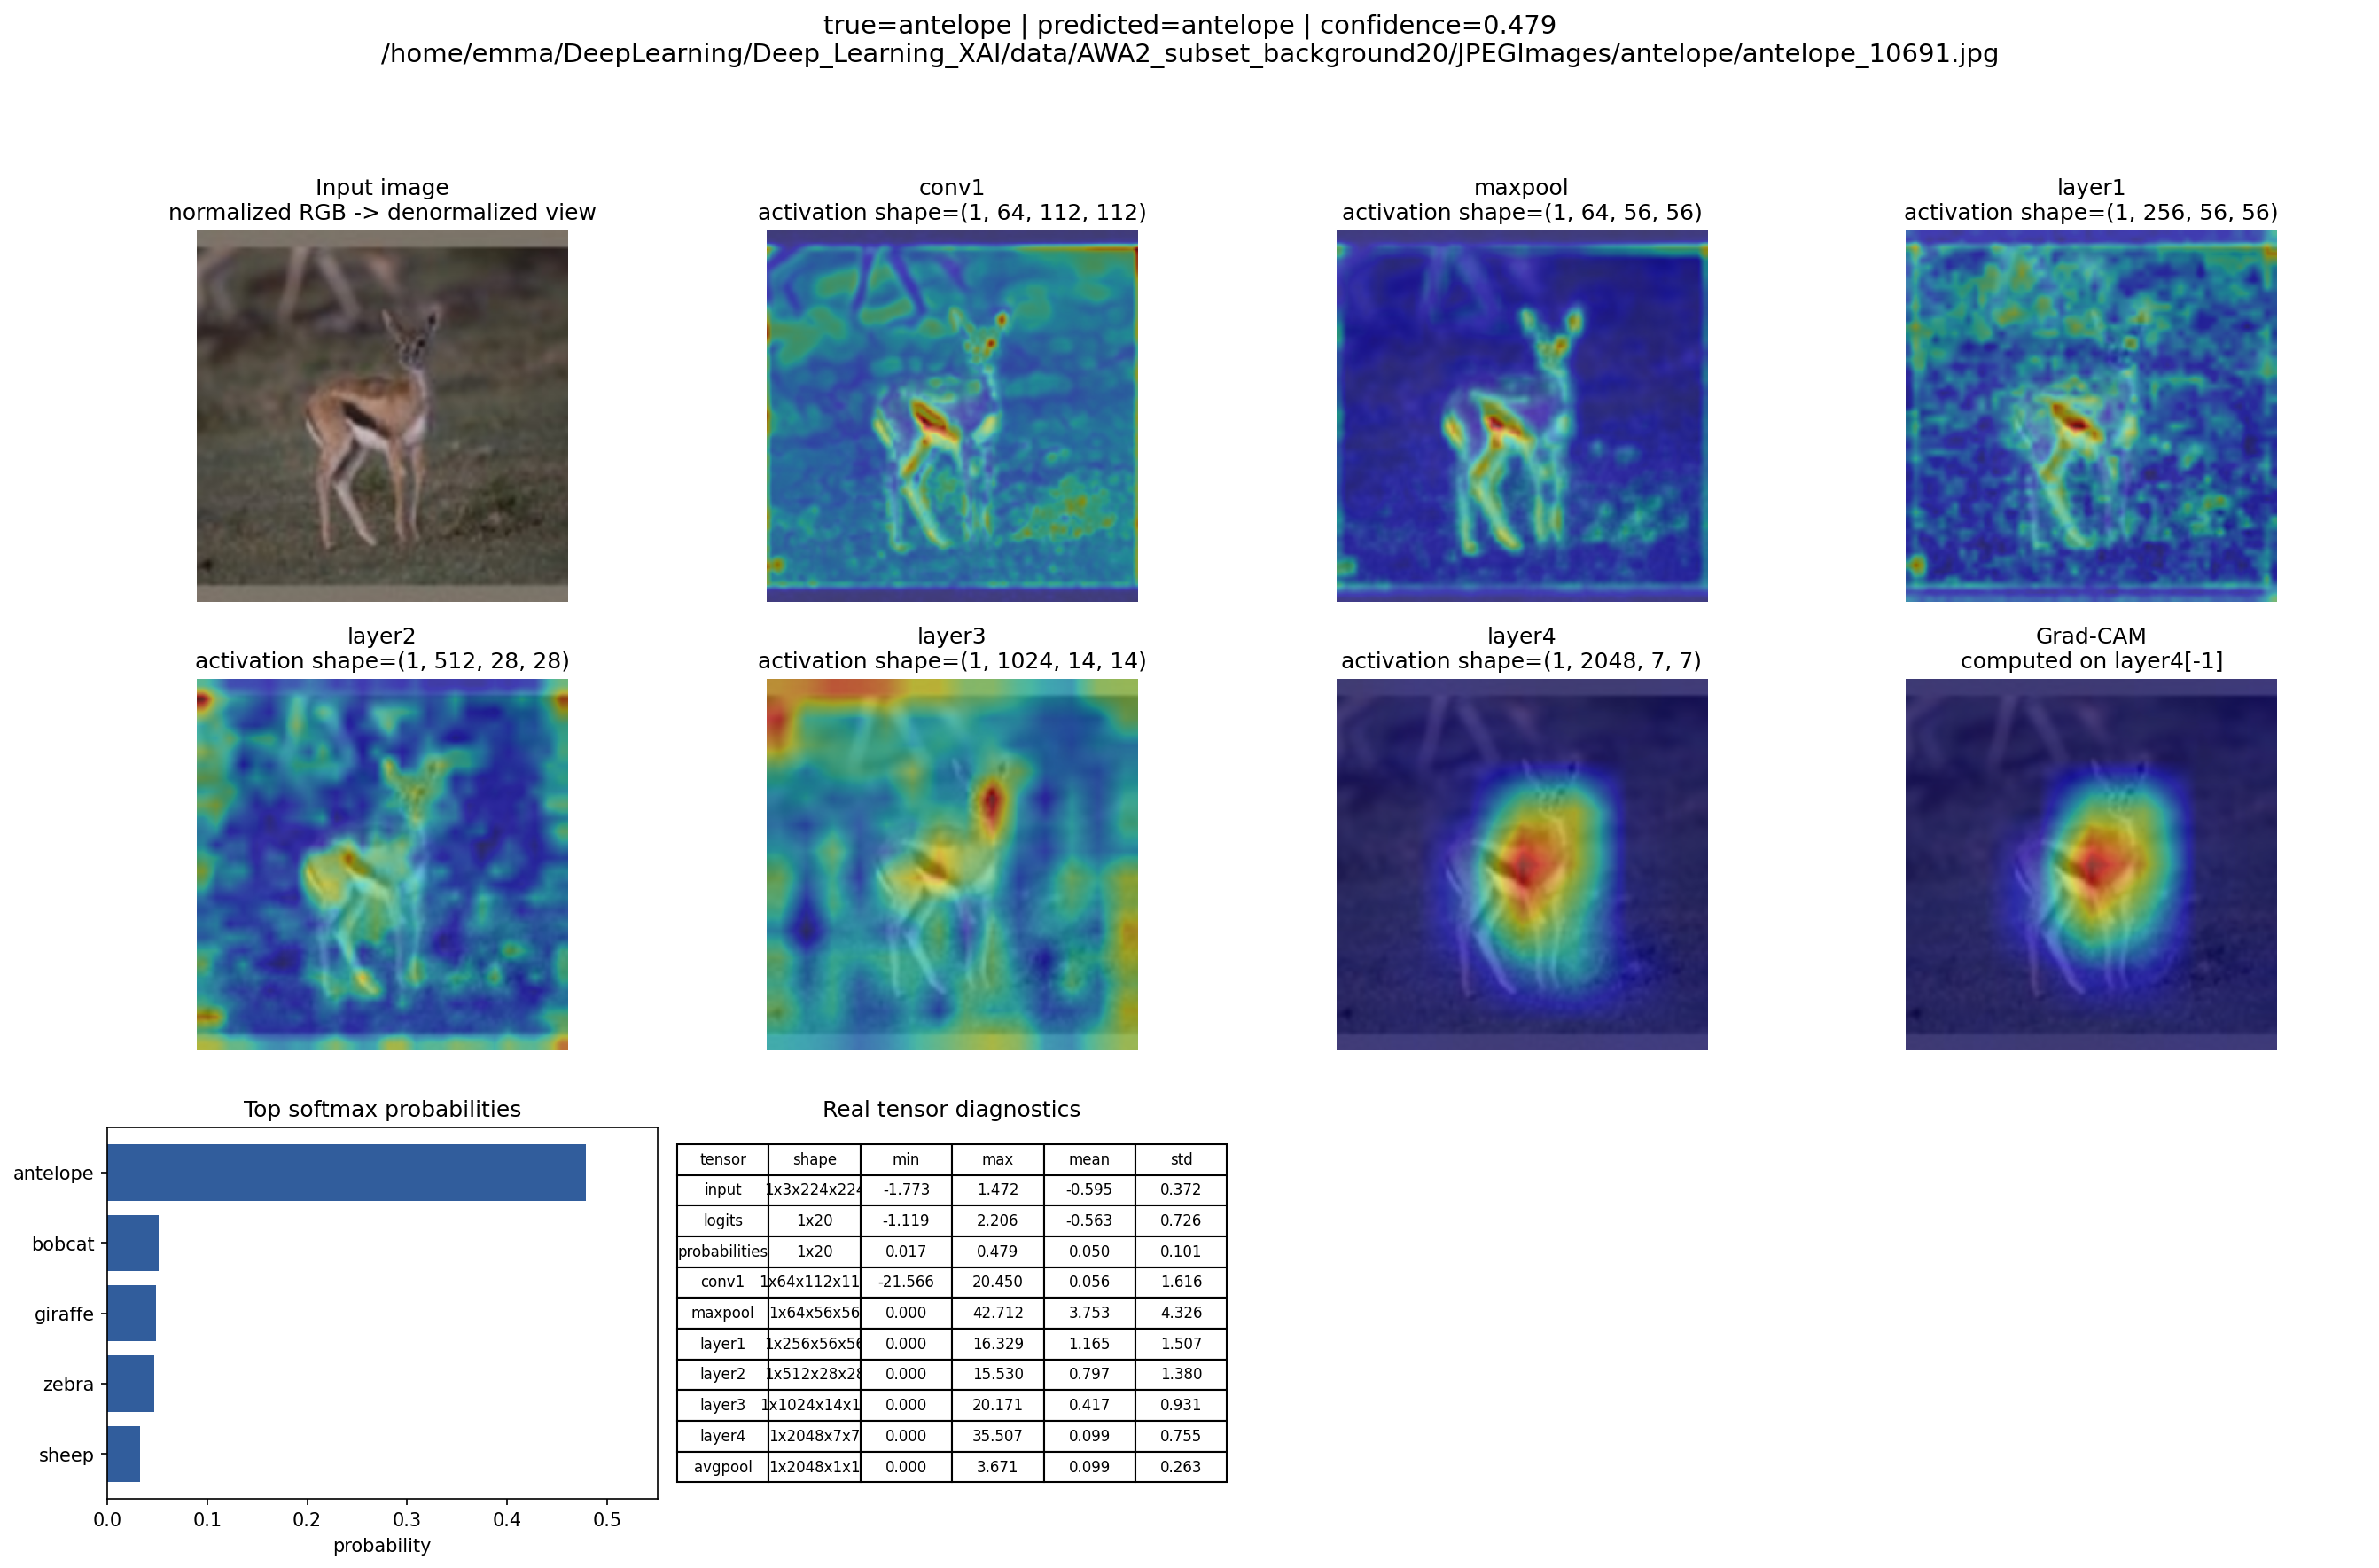

In [8]:
save_prediction_trace_figure(
    image=image,
    trace=trace,
    class_names=class_names,
    output_path=OUTPUT,
    true_label=int(label),
    image_path=image_path,
)

save_trace_json(
    image=image,
    trace=trace,
    class_names=class_names,
    output_path=TRACE_JSON,
    true_label=int(label),
    image_path=image_path,
)

print("trace json:", TRACE_JSON)

display(Image(filename=str(OUTPUT)))

## How to interpret this inspection

- `conv1` and `maxpool` show early visual primitives, such as color transitions, contours and texture.
- `layer1` and `layer2` compress local patterns into more structured visual parts.
- `layer3` and `layer4` are the fine-tuned high-level blocks in this project.
- `layer4` has low spatial resolution, so Grad-CAM starts from coarse evidence and is upsampled for display.
- The softmax probability reports confidence, but the attribution map should be read as evidence for the selected target score, not as proof that the model used the correct semantic reason.